First, install the Python libraries we'll need before we start.

In [3]:
!pip install -q scikit-image tqdm joblib skl2onnx onnx onnxruntime
print("All packages ready.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.2/317.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 16.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.2 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.2 which is incompatible.
All packages ready.


Get the dataset from Google Drive and extract the zip file's contents.

In [4]:
from google.colab import drive
import os, zipfile, glob

try:
    drive.mount('/content/drive', force_remount=True)
except Exception as e:
    raise RuntimeError(
        "Drive mount failed. In Colab, click the folder icon on the left, "
        "then the Drive icon, and approve the popup. If it still fails, "
        "Runtime > Disconnect and delete runtime, then try again."
    ) from e

assert os.path.ismount('/content/drive') or os.path.exists('/content/drive/MyDrive'), (
    "Drive mounted but MyDrive isn't visible -- try Runtime > Restart session and re-run.")

# Instead of relying on one hardcoded path, search all of MyDrive for the zip.
# This way it doesn't matter which folder you actually put BananaLeaf_Dataset.zip in.
ZIP_NAME = "banana_leafdataset.zip"
SEARCH_ROOT = "/content/drive/MyDrive"

matches = glob.glob(os.path.join(SEARCH_ROOT, "**", ZIP_NAME), recursive=True)

assert len(matches) > 0, (
    f"Couldn't find {ZIP_NAME} anywhere inside {SEARCH_ROOT}. "
    "Open the Google Drive app/website, confirm the file is named exactly "
    "'BananaLeaf_Dataset.zip' (no extra characters like ' (1)'), and that it's "
    "uploaded somewhere under My Drive, then re-run this cell."
)

if len(matches) > 1:
    print("Found multiple matches, using the first one:")
    for m in matches:
        print("  -", m)

DRIVE_ZIP = matches[0]
DRIVE_DIR = os.path.dirname(DRIVE_ZIP)
print("Using dataset zip at:", DRIVE_ZIP)

# Extracted straight onto Drive (not /content) so it PERSISTS across
# sessions -- add new real photos or run the augmentation cell below
# and they stay saved here permanently.
EXTRACT_DIR = f"{DRIVE_DIR}/BananaLeaf_Dataset_extracted"
if not os.path.exists(EXTRACT_DIR):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    try:
        with zipfile.ZipFile(DRIVE_ZIP, 'r') as z:
            z.extractall(EXTRACT_DIR)
    except zipfile.BadZipFile:
        raise RuntimeError(
            f"{DRIVE_ZIP} exists but isn't a valid zip file -- it may have "
            "uploaded incompletely. Re-upload it to Drive and re-run this cell."
        )
    print("Extracted dataset to", EXTRACT_DIR)
else:
    print("Dataset already extracted at", EXTRACT_DIR)


Mounted at /content/drive
Using dataset zip at: /content/drive/MyDrive/leaf_model/banana_leafdataset.zip
Dataset already extracted at /content/drive/MyDrive/leaf_model/BananaLeaf_Dataset_extracted


Find where the dataset folders (SINGLE_LABEL, MULTI_LABEL, NEGATIVE) are saved.

In [5]:
import glob

REQUIRED_TOP = ["SINGLE_LABEL", "MULTI_LABEL", "NEGATIVE"]

def find_dataset_root(root=EXTRACT_DIR):
    for dirpath, dirnames, _ in os.walk(root):
        if all(any(d == req for d in dirnames) for req in REQUIRED_TOP):
            return dirpath
    return None

DATASET_ROOT = find_dataset_root()
print("Detected dataset root:", DATASET_ROOT)
assert DATASET_ROOT is not None, (
    f"Could not find a folder containing SINGLE_LABEL/, MULTI_LABEL/, and NEGATIVE/ inside {EXTRACT_DIR}. "
    "Check that your zip preserves the BananaLeaf_Dataset folder structure."
)

SINGLE_DIR = os.path.join(DATASET_ROOT, "SINGLE_LABEL")
MULTI_DIR  = os.path.join(DATASET_ROOT, "MULTI_LABEL")
NEG_DIR    = os.path.join(DATASET_ROOT, "NEGATIVE")

for label, d in [("SINGLE_LABEL", SINGLE_DIR), ("MULTI_LABEL", MULTI_DIR), ("NEGATIVE", NEG_DIR)]:
    subs = sorted(os.listdir(d))
    print(f"\n{label}/ -> {subs}")
    for s in subs:
        n = len(glob.glob(os.path.join(d, s, "*")))
        print(f"   {s}: {n} images")


Detected dataset root: /content/drive/MyDrive/leaf_model/BananaLeaf_Dataset_extracted/banana_leafdataset

SINGLE_LABEL/ -> ['Cordana', 'Healthy', 'Pestalotiopsis', 'Sigatoka']
   Cordana: 1220 images
   Healthy: 1002 images
   Pestalotiopsis: 1320 images
   Sigatoka: 924 images

MULTI_LABEL/ -> ['cordana_pestalotiopsis', 'cordana_pestalotiopsis_sigatoka', 'cordana_sigatoka', 'pestalotiopsis_sigatoka']
   cordana_pestalotiopsis: 250 images
   cordana_pestalotiopsis_sigatoka: 256 images
   cordana_sigatoka: 250 images
   pestalotiopsis_sigatoka: 250 images

NEGATIVE/ -> ['background', 'objects', 'other_plant', 'person']
   background: 23 images
   objects: 21 images
   other_plant: 154 images
   person: 15 images


(Optional) Create extra images by rotating, flipping, and adjusting the color of existing photos, so we have more training data.

In [6]:
import cv2
import numpy as np
import os, glob

# Fix: multipliers used to be backwards -- the class with the MOST
# originals (Sigatoka, 462) got the highest multiplier (3x -> 1,848 final),
# while the class with the FEWEST originals (Pestalotiopsis, 330) got NONE
# (0x -> stayed at 330). That widened the imbalance instead of fixing it,
# and matches exactly which disease heads ended up weakest in training
# (Cordana/Pestalotiopsis) vs strongest (Sigatoka). Rebalanced so all four
# classes land in a similar final range (roughly 900-1300 images):
AUGMENT_CLASSES = {
    "SINGLE_LABEL/Sigatoka": 1,        # 462 -> 924   (was 3 -> 1,848)
    "SINGLE_LABEL/Healthy": 2,         # 334 -> 1,002 (unchanged)
    "SINGLE_LABEL/Cordana": 3,         # 305 -> 1,220 (was 1 -> 610)
    "SINGLE_LABEL/Pestalotiopsis": 3,  # 330 -> 1,320 (was 0 -> 330)
}

def augment_image(img):
    h, w = img.shape[:2]

    angle = np.random.uniform(-25, 25)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT101)

    if np.random.rand() < 0.5:
        img = cv2.flip(img, 1)

    alpha = np.random.uniform(0.85, 1.15)
    beta = np.random.uniform(-15, 15)
    img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta)

    noise = np.random.normal(0, 3, img.shape).astype(np.int16)
    img = np.clip(img.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return img

total_written = 0
for rel_class_dir, n_aug in AUGMENT_CLASSES.items():
    class_dir = os.path.join(DATASET_ROOT, rel_class_dir)
    originals = [p for p in glob.glob(os.path.join(class_dir, "*"))
                 if "_aug" not in os.path.basename(p)]
    print(f"{rel_class_dir}: {len(originals)} original image(s) -> "
          f"generating {n_aug}x augmented copies each")

    for path in originals:
        img = cv2.imread(path)
        if img is None:
            print(f"  (skipped, could not read: {path})")
            continue
        base, ext = os.path.splitext(path)
        for i in range(n_aug):
            aug = augment_image(img)
            out_path = f"{base}_aug{i + 1}{ext}"
            cv2.imwrite(out_path, aug)
            total_written += 1

print(f"\nDone. Wrote {total_written} augmented image(s).")
print("Next: delete/rename the cached features_all.csv on Drive, then re-run "
      "the dataset-scan cell above so the new files are picked up.")


SINGLE_LABEL/Sigatoka: 462 original image(s) -> generating 1x augmented copies each
SINGLE_LABEL/Healthy: 334 original image(s) -> generating 2x augmented copies each
SINGLE_LABEL/Cordana: 305 original image(s) -> generating 3x augmented copies each
SINGLE_LABEL/Pestalotiopsis: 330 original image(s) -> generating 3x augmented copies each

Done. Wrote 3035 augmented image(s).
Next: delete/rename the cached features_all.csv on Drive, then re-run the dataset-scan cell above so the new files are picked up.


This cell defines the functions used to preprocess each image (resize, blur, HSV) and extract features (the numbers that describe the leaf).

In [7]:
import cv2
import numpy as np
from skimage.feature import graycomatrix, graycoprops

IMG_SIZE = 200
GLCM_PROPS = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]


# Shared preprocessing

def preprocess(img_bgr, size=IMG_SIZE):
    img = cv2.resize(img_bgr, (size, size), interpolation=cv2.INTER_AREA)
    img = cv2.GaussianBlur(img, (5, 5), 0)
    return img

def segment_leaf(img_bgr):
    """Isolate leaf/vegetation pixels from background using K-means clustering
    (2 clusters over HSV color) to split the image into two regions, then Otsu's
    thresholding on the Saturation channel to automatically decide WHICH of the
    two K-means clusters is the leaf region (the more saturated one) instead of
    relying on a fixed hand-picked HSV range. A fixed-range fallback is kept for
    washed-out photos where neither cluster clears the Otsu cutoff, so the mask
    never silently comes back empty."""
    img = preprocess(img_bgr)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # --- K-means: cluster pixels into 2 groups by HSV color ---
    Z = hsv.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 0.5)
    _, labels, _ = cv2.kmeans(Z, 2, None, criteria, 5, cv2.KMEANS_PP_CENTERS)
    labels = labels.reshape(hsv.shape[:2])

    # --- Otsu's thresholding on Saturation: finds the cutoff that best separates
    # vivid (leaf/lesion) pixels from dull (wall/floor/background) pixels. Used
    # here to pick which K-means cluster is "leaf" rather than a fixed range. ---
    sat = hsv[:, :, 1]
    otsu_thresh, _ = cv2.threshold(sat, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    cluster0_sat = sat[labels == 0].mean() if np.any(labels == 0) else 0.0
    cluster1_sat = sat[labels == 1].mean() if np.any(labels == 1) else 0.0
    leaf_label = 0 if cluster0_sat >= cluster1_sat else 1

    if max(cluster0_sat, cluster1_sat) < otsu_thresh:
        # Neither cluster is clearly "vivid" -- fall back to the fixed HSV range
        # rather than risk an empty/garbage mask on a washed-out photo.
        lower = np.array([15, 25, 25])
        upper = np.array([95, 255, 255])
        mask = cv2.inRange(hsv, lower, upper)
    else:
        mask = np.where(labels == leaf_label, 255, 0).astype(np.uint8)

    kernel = np.ones((5, 5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    return img, hsv, mask

# STAGE 1 features — "is this a banana leaf at all?"

LEAF_FEATURE_NAMES = ["veg_ratio", "circularity", "largest_blob_ratio", "aspect", "extent",
                       "hue_mean", "hue_std", "sat_mean", "val_mean", "edge_density"]

def leaf_presence_features(img_bgr):
    img, hsv, mask = segment_leaf(img_bgr)
    total = mask.size
    veg_ratio = float((mask > 0).sum()) / total

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        perim = cv2.arcLength(c, True) + 1e-6
        circularity = 4 * np.pi * area / (perim * perim)
        largest_blob_ratio = area / total
        x, y, w, h = cv2.boundingRect(c)
        aspect = w / (h + 1e-6)
        extent = area / (w * h + 1e-6)
    else:
        circularity = largest_blob_ratio = aspect = extent = 0.0

    h_chan = hsv[:, :, 0].astype(np.float64)
    s_chan = hsv[:, :, 1].astype(np.float64)
    v_chan = hsv[:, :, 2].astype(np.float64)
    hue_mean, hue_std = h_chan.mean(), h_chan.std()
    sat_mean = s_chan.mean()
    val_mean = v_chan.mean()

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 50, 150)
    edge_density = float((edges > 0).sum()) / total

    return [veg_ratio, circularity, largest_blob_ratio, aspect, extent,
            hue_mean, hue_std, sat_mean, val_mean, edge_density]

# STAGE 2 features — color-moment + GLCM texture for disease detection

DISEASE_FEATURE_NAMES = (
    [f"{c}_{stat}" for c in ["H", "S", "V"] for stat in ["mean", "std", "skew"]] +
    [f"glcm_{p}" for p in GLCM_PROPS]
)

def color_moments(hsv_img, mask):
    feats = []
    m = mask > 0
    if m.sum() < 20:
        m = np.ones_like(mask, dtype=bool)
    for ch in range(3):
        chan = hsv_img[:, :, ch][m].astype(np.float64)
        mean = chan.mean()
        std = chan.std()
        third_moment = ((chan - mean) ** 3).mean()
        skew = np.sign(third_moment) * (abs(third_moment) ** (1 / 3))
        feats.extend([mean, std, skew])
    return feats

def glcm_features(gray_img, mask):
    m = mask > 0
    if m.sum() < 20:
        roi = gray_img
    else:
        ys, xs = np.where(m)
        y0, y1, x0, x1 = ys.min(), ys.max() + 1, xs.min(), xs.max() + 1
        roi = gray_img[y0:y1, x0:x1]
    roi = (roi / 4).astype(np.uint8)  # 64 gray levels -> cheaper GLCM
    glcm = graycomatrix(roi, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                         levels=64, symmetric=True, normed=True)
    return [graycoprops(glcm, prop).mean() for prop in GLCM_PROPS]

def disease_features(img_bgr):
    img, hsv, mask = segment_leaf(img_bgr)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return color_moments(hsv, mask) + glcm_features(gray, mask)

print("Feature extractors ready:")
print(" leaf features   :", LEAF_FEATURE_NAMES)
print(" disease features:", DISEASE_FEATURE_NAMES)


Feature extractors ready:
 leaf features   : ['veg_ratio', 'circularity', 'largest_blob_ratio', 'aspect', 'extent', 'hue_mean', 'hue_std', 'sat_mean', 'val_mean', 'edge_density']
 disease features: ['H_mean', 'H_std', 'H_skew', 'S_mean', 'S_std', 'S_skew', 'V_mean', 'V_std', 'V_skew', 'glcm_contrast', 'glcm_dissimilarity', 'glcm_homogeneity', 'glcm_energy', 'glcm_correlation', 'glcm_ASM']


Just shows a few sample images from the dataset, so we can check that everything loaded correctly.

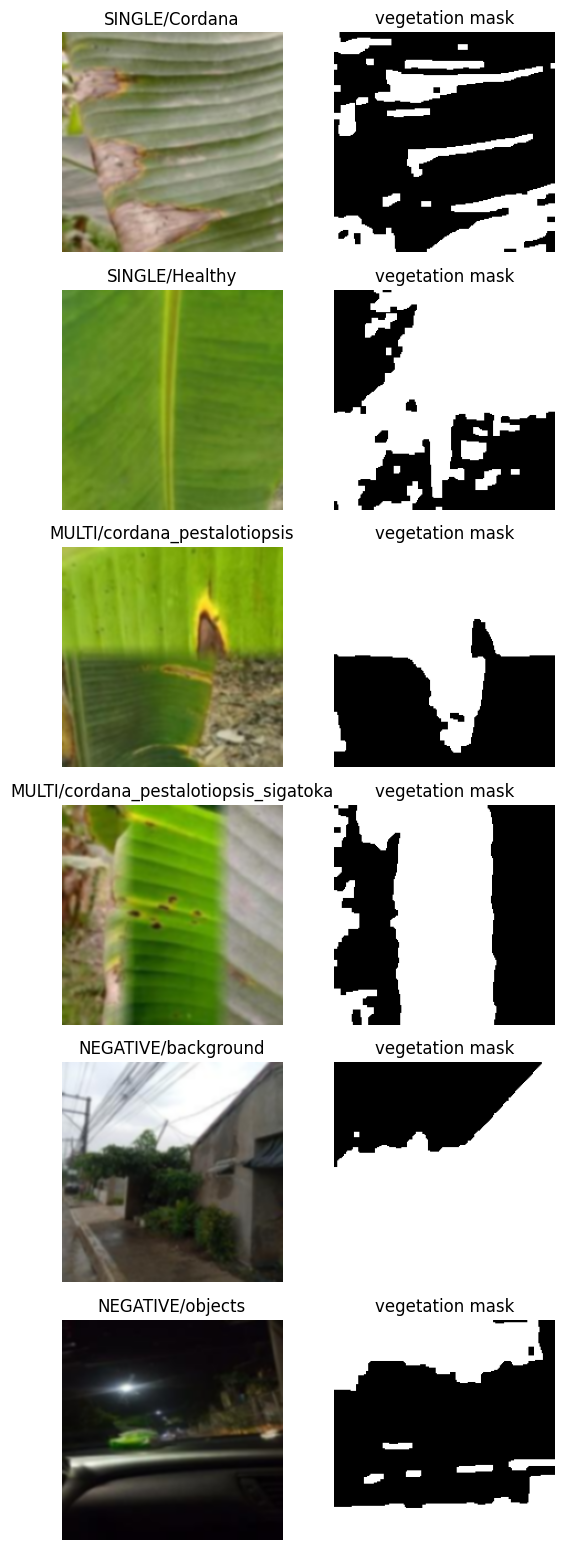

In [8]:
import matplotlib.pyplot as plt

def show_samples():
    picks = []
    for d, label in [(SINGLE_DIR, "SINGLE"), (MULTI_DIR, "MULTI"), (NEG_DIR, "NEGATIVE")]:
        subs = sorted(os.listdir(d))
        for s in subs[:2]:
            imgs = glob.glob(os.path.join(d, s, "*"))
            if imgs:
                picks.append((f"{label}/{s}", imgs[0]))

    fig, axes = plt.subplots(len(picks), 2, figsize=(6, 2.6 * len(picks)))
    for row, (title, path) in enumerate(picks):
        img_bgr = cv2.imread(path)
        _, _, mask = segment_leaf(img_bgr)
        axes[row, 0].imshow(cv2.cvtColor(preprocess(img_bgr), cv2.COLOR_BGR2RGB))
        axes[row, 0].set_title(title); axes[row, 0].axis("off")
        axes[row, 1].imshow(mask, cmap="gray")
        axes[row, 1].set_title("vegetation mask"); axes[row, 1].axis("off")
    plt.tight_layout()
    plt.show()

show_samples()


Build a list (manifest) of every image with its label: whether it's a leaf or not, and which disease it shows.

In [9]:
DISEASES = ["cordana", "sigatoka", "pestalotiopsis"]  # order defines the multi-hot vector

def multihot_from_foldername(name):
    n = name.lower()
    return [1 if d in n else 0 for d in DISEASES]

rows = []
for base_dir in [SINGLE_DIR, MULTI_DIR]:
    for folder in sorted(glob.glob(os.path.join(base_dir, "*"))):
        cname = os.path.basename(folder)
        multi = multihot_from_foldername(cname)
        for p in glob.glob(os.path.join(folder, "*")):
            rows.append({"path": p, "is_leaf": 1, "class": cname,
                         "y_cordana": multi[0], "y_sigatoka": multi[1], "y_pesta": multi[2]})

for folder in sorted(glob.glob(os.path.join(NEG_DIR, "*"))):
    cname = "NEGATIVE_" + os.path.basename(folder)
    for p in glob.glob(os.path.join(folder, "*")):
        rows.append({"path": p, "is_leaf": 0, "class": cname,
                     "y_cordana": 0, "y_sigatoka": 0, "y_pesta": 0})

import pandas as pd
manifest = pd.DataFrame(rows)
print("Total images:", len(manifest))
print(manifest["class"].value_counts())


Total images: 5685
class
Pestalotiopsis                     1320
Cordana                            1220
Healthy                            1002
Sigatoka                            924
cordana_pestalotiopsis_sigatoka     256
cordana_pestalotiopsis              250
cordana_sigatoka                    250
pestalotiopsis_sigatoka             250
NEGATIVE_other_plant                154
NEGATIVE_background                  23
NEGATIVE_objects                     21
NEGATIVE_person                      15
Name: count, dtype: int64


Extract the features (numbers) for every image using the functions above. This is saved to a CSV file so we don't have to redo it every time we re-run the notebook.

In [10]:
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

FEATURES_CSV = f"{DRIVE_DIR}/features_all.csv"   # Drive-backed: survives disconnects

def extract_one(path):
    img = cv2.imread(path)
    if img is None:
        return None
    return leaf_presence_features(img) + disease_features(img)

if os.path.exists(FEATURES_CSV):
    print(f"Loading cached features from Drive: {FEATURES_CSV}")
    full = pd.read_csv(FEATURES_CSV)
else:
    print("Extracting features for all images (this runs once, then is cached to Drive)...")
    results = Parallel(n_jobs=-1)(
        delayed(extract_one)(p) for p in tqdm(manifest["path"].tolist())
    )
    ok_mask = [r is not None for r in results]
    manifest_ok = manifest[ok_mask].reset_index(drop=True)
    feat_matrix = np.array([r for r in results if r is not None])
    all_names = LEAF_FEATURE_NAMES + DISEASE_FEATURE_NAMES
    feat_df = pd.DataFrame(feat_matrix, columns=all_names)
    full = pd.concat([manifest_ok, feat_df], axis=1)
    full.to_csv(FEATURES_CSV, index=False)
    print(f"Saved features to {FEATURES_CSV}")

print(full.shape)
full.head()


Loading cached features from Drive: /content/drive/MyDrive/leaf_model/features_all.csv
(5685, 31)


,path,is_leaf,class,y_cordana,y_sigatoka,y_pesta,veg_ratio,circularity,largest_blob_ratio,aspect,...,S_skew,V_mean,V_std,V_skew,glcm_contrast,glcm_dissimilarity,glcm_homogeneity,glcm_energy,glcm_correlation,glcm_ASM
0,/content/drive/MyDrive/leaf_model/BananaLeaf_D...,1,Cordana,1,0,0,0.363875,0.211676,0.162463,1.000000,...,-17.525751,89.505064,32.768269,12.949810,2.674574,1.087782,0.589246,0.084590,0.984108,0.007187
1,/content/drive/MyDrive/leaf_model/BananaLeaf_D...,1,Cordana,1,0,0,0.268125,0.142570,0.089800,1.493506,...,34.540976,117.640067,23.510054,21.566676,3.404993,1.224973,0.558407,0.095648,0.966036,0.009430
2,/content/drive/MyDrive/leaf_model/BananaLeaf_D...,1,Cordana,1,0,0,0.122875,0.604536,0.119225,0.882979,...,-26.369803,77.639064,17.198309,-3.609789,2.966719,1.035924,0.617874,0.107945,0.992959,0.011693
3,/content/drive/MyDrive/leaf_model/BananaLeaf_D...,1,Cordana,1,0,0,0.084300,0.444096,0.080775,1.682540,...,-22.459392,77.555325,20.099636,-3.391180,4.220157,1.055278,0.653037,0.129799,0.988134,0.016890
4,/content/drive/MyDrive/leaf_model/BananaLeaf_D...,1,Cordana,1,0,0,0.183075,0.146182,0.058375,0.325581,...,13.624783,133.923119,30.074725,42.550425,1.233578,0.612257,0.738722,0.142671,0.982952,0.020564


Split the data into training and testing sets, then scale the features.

**Fix:** grouped by the original photo, so an image and its augmented copies (`_aug1`, `_aug2`, ...) always stay on the same side of the split -- this prevents the model from being tested on a leaf it effectively already saw during training.

In [11]:
import re
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler

# ---- Group by ORIGINAL photo so augmented copies never leak across the
# train/test split. "leaf_aug1.jpg" and "leaf_aug2.jpg" are near-duplicates
# of "leaf.jpg" (same leaf, just rotated/flipped/recolored) -- without this,
# a plain train_test_split can put the original in train and its augmented
# twin in test (or vice versa), so the model is effectively evaluated on
# leaves it already saw. That inflates test accuracy without the model
# actually getting better at real, unseen photos.
def base_group(path):
    name = os.path.basename(path)
    return re.sub(r"_aug\d+(?=\.[^.]+$)", "", name)

full["group"] = full["path"].apply(base_group)

# ---- Stage 1: Leaf Gate split + scale (grouped + stratified) ----
X1 = full[LEAF_FEATURE_NAMES].values
y1 = full["is_leaf"].values
groups1 = full["group"].values

sgkf1 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx1, test_idx1 = next(sgkf1.split(X1, y1, groups=groups1))
X1_train, X1_test = X1[train_idx1], X1[test_idx1]
y1_train, y1_test = y1[train_idx1], y1[test_idx1]

# Sanity check: no original photo should have copies on both sides.
assert set(groups1[train_idx1]).isdisjoint(set(groups1[test_idx1])), \
    "Leak detected: some photo has copies in both train and test!"

leaf_scaler = StandardScaler().fit(X1_train)
X1_train_s, X1_test_s = leaf_scaler.transform(X1_train), leaf_scaler.transform(X1_test)

# ---- Stage 2: Disease heads split + scale (banana-leaf rows only, grouped) ----
leaf_only = full[full["is_leaf"] == 1].reset_index(drop=True)
X2 = leaf_only[DISEASE_FEATURE_NAMES].values
Y2 = leaf_only[["y_cordana", "y_sigatoka", "y_pesta"]].values
strat_col = leaf_only["class"]
groups2 = leaf_only["group"].values

sgkf2 = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
train_idx2, test_idx2 = next(sgkf2.split(X2, strat_col, groups=groups2))
X2_train, X2_test = X2[train_idx2], X2[test_idx2]
Y2_train, Y2_test = Y2[train_idx2], Y2[test_idx2]

assert set(groups2[train_idx2]).isdisjoint(set(groups2[test_idx2])), \
    "Leak detected: some photo has copies in both train and test!"

disease_scaler = StandardScaler().fit(X2_train)
X2_train_s, X2_test_s = disease_scaler.transform(X2_train), disease_scaler.transform(X2_test)

DISEASE_NAMES = ["Cordana", "Sigatoka", "Pestalotiopsis"]

print("Stage 1 (leaf gate) split:", X1_train_s.shape, X1_test_s.shape)
print("Stage 2 (disease heads) split:", X2_train_s.shape, X2_test_s.shape)
print("No leakage between train/test -- verified by group check above.")


Stage 1 (leaf gate) split: (4546, 10) (1139, 10)
Stage 2 (disease heads) split: (4378, 15) (1094, 15)
No leakage between train/test -- verified by group check above.


## Compare SVM and Random Forest

Before using Random Forest as the final model, we also try SVM and compare the two. Whichever wins is used for training and export below.

Compare Random Forest and SVM here: which one has higher accuracy and F1 score. Whichever wins is the one used in the next step.


=== Stage 1: Leaf Gate — SVM vs Random Forest ===


,Model,Test Acc,Test F1,5-fold CV F1,Train time (s),Inference (ms/sample)
0,Random Forest,0.9833,0.9914,0.9892,3.505,0.0295
1,SVM (RBF),0.9719,0.9853,0.9799,0.084,0.0213



=== Stage 2: Cordana detector — SVM vs Random Forest ===


,Model,Test Acc,Test F1,5-fold CV F1,Train time (s),Inference (ms/sample)
0,SVM (RBF),0.7925,0.7301,0.6901,0.612,0.1285
1,Random Forest,0.7989,0.6953,0.7276,5.343,0.0493



=== Stage 2: Sigatoka detector — SVM vs Random Forest ===


,Model,Test Acc,Test F1,5-fold CV F1,Train time (s),Inference (ms/sample)
0,Random Forest,0.8537,0.7324,0.6709,5.468,0.0792
1,SVM (RBF),0.7870,0.6847,0.6449,0.529,0.1128



=== Stage 2: Pestalotiopsis detector — SVM vs Random Forest ===


,Model,Test Acc,Test F1,5-fold CV F1,Train time (s),Inference (ms/sample)
0,Random Forest,0.7888,0.7012,0.7359,7.452,0.0684
1,SVM (RBF),0.7523,0.7006,0.6812,0.943,0.2378


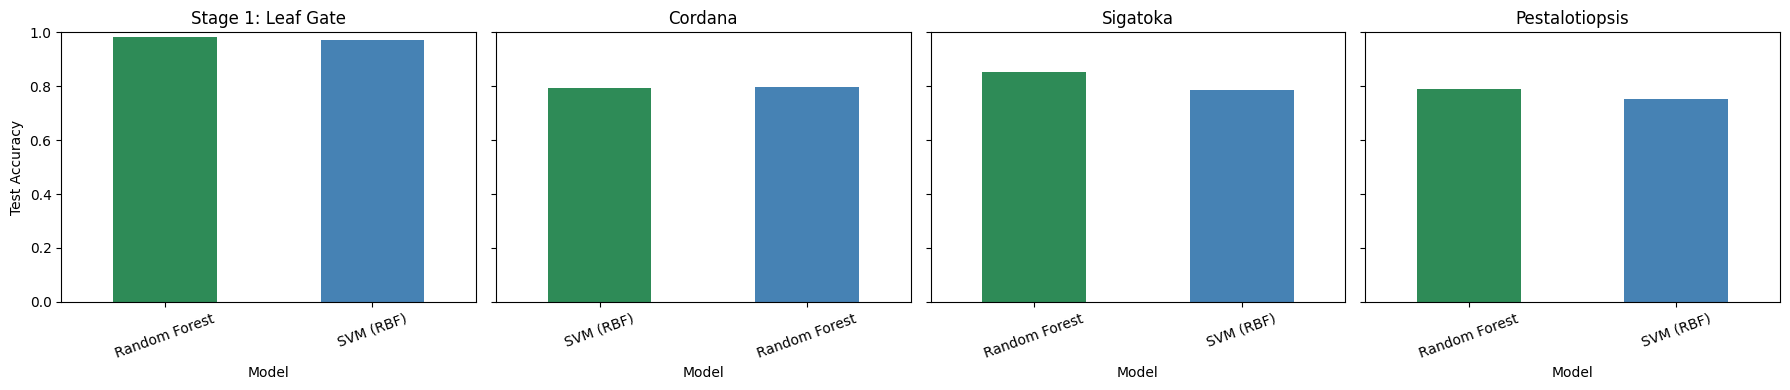


=== Test Accuracy summary across all tasks (SVM vs Random Forest) ===


,Stage1_LeafGate,Stage2_Cordana,Stage2_Sigatoka,Stage2_Pestalotiopsis
Model,,,,
Random Forest,0.9833,0.7989,0.8537,0.7888
SVM (RBF),0.9719,0.7925,0.7870,0.7523



=== Test F1 summary across all tasks (SVM vs Random Forest) ===


,Stage1_LeafGate,Stage2_Cordana,Stage2_Sigatoka,Stage2_Pestalotiopsis
Model,,,,
Random Forest,0.9914,0.6953,0.7324,0.7012
SVM (RBF),0.9853,0.7301,0.6847,0.7006



Accuracy wins — Random Forest: 4/4 tasks | SVM (RBF): 0/4 tasks | Ties: 0


In [12]:
# ================= MODEL COMPARISON: SVM vs Random Forest =================
import time
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, f1_score

CANDIDATES = {
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", class_weight="balanced", random_state=42),
}

def compare_models(X_train, X_test, y_train, y_test, task_name):
    rows = []
    n_classes = len(set(y_train))
    for name, clf in CANDIDATES.items():
        t0 = time.time()
        clf.fit(X_train, y_train)
        train_time = time.time() - t0

        t0 = time.time()
        pred = clf.predict(X_test)
        infer_ms = (time.time() - t0) / len(X_test) * 1000  # ms/sample

        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average="binary" if n_classes == 2 else "macro")
        cv_f1 = cross_val_score(clf, X_train, y_train, cv=5,
                                 scoring="f1" if n_classes == 2 else "f1_macro").mean()

        rows.append({
            "Model": name,
            "Test Acc": round(acc, 4),
            "Test F1": round(f1, 4),
            "5-fold CV F1": round(cv_f1, 4),
            "Train time (s)": round(train_time, 3),
            "Inference (ms/sample)": round(infer_ms, 4),
        })

    df = pd.DataFrame(rows).sort_values("Test F1", ascending=False).reset_index(drop=True)
    print(f"\n=== {task_name} \u2014 SVM vs Random Forest ===")
    display(df)
    return df

# Stage 1: Leaf Gate (reuses X1_train_s / X1_test_s / y1_train / y1_test from the cell above)
results_stage1 = compare_models(X1_train_s, X1_test_s, y1_train, y1_test, "Stage 1: Leaf Gate")

# Stage 2: one comparison per disease head (reuses X2_train_s / Y2_train / DISEASE_NAMES from the cell above)
results_stage2 = {}
for i, name in enumerate(DISEASE_NAMES):
    results_stage2[name] = compare_models(
        X2_train_s, X2_test_s, Y2_train[:, i], Y2_test[:, i], f"Stage 2: {name} detector"
    )

# ---- summary chart: Test Accuracy per model, per task ----
fig, axes = plt.subplots(1, len(DISEASE_NAMES) + 1, figsize=(4.5 * (len(DISEASE_NAMES) + 1), 4), sharey=True)
results_stage1.set_index("Model")["Test Acc"].plot(kind="bar", ax=axes[0], title="Stage 1: Leaf Gate",
                                                     color=["seagreen", "steelblue"])
axes[0].set_ylabel("Test Accuracy")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for ax, name in zip(axes[1:], DISEASE_NAMES):
    results_stage2[name].set_index("Model")["Test Acc"].plot(kind="bar", ax=ax, title=name,
                                                               color=["seagreen", "steelblue"])
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

# ---- combined table for easy copy into your paper ----
all_results = {"Stage1_LeafGate": results_stage1, **{f"Stage2_{k}": v for k, v in results_stage2.items()}}
acc_summary = pd.concat(
    [df.set_index("Model")["Test Acc"].rename(task) for task, df in all_results.items()],
    axis=1
)
f1_summary = pd.concat(
    [df.set_index("Model")["Test F1"].rename(task) for task, df in all_results.items()],
    axis=1
)
print("\n=== Test Accuracy summary across all tasks (SVM vs Random Forest) ===")
display(acc_summary)
print("\n=== Test F1 summary across all tasks (SVM vs Random Forest) ===")
display(f1_summary)

# ---- overall winner call ----
rf_wins = (acc_summary.loc["Random Forest"] > acc_summary.loc["SVM (RBF)"]).sum()
svm_wins = (acc_summary.loc["SVM (RBF)"] > acc_summary.loc["Random Forest"]).sum()
ties = len(acc_summary.columns) - rf_wins - svm_wins
print(f"\nAccuracy wins \u2014 Random Forest: {rf_wins}/{len(acc_summary.columns)} tasks | "
      f"SVM (RBF): {svm_wins}/{len(acc_summary.columns)} tasks | Ties: {ties}")


Tune the Random Forest model for Stage 1 (leaf gate: is it a leaf or not) using GridSearchCV to find the best settings.

Stage 1 (leaf gate) winner from the comparison above: Random Forest
Best Stage-1 params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}

=== STAGE 1: Leaf Gate (is_leaf) ===
                   precision    recall  f1-score   support

NOT a banana leaf       0.87      0.64      0.74        42
      banana leaf       0.99      1.00      0.99      1097

         accuracy                           0.98      1139
        macro avg       0.93      0.82      0.87      1139
     weighted avg       0.98      0.98      0.98      1139



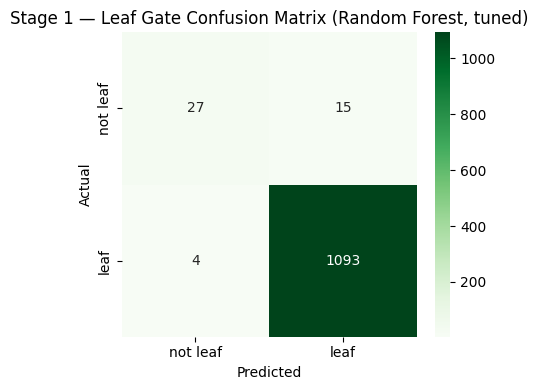

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns

def tune_winner(winner_name, X_train, y_train):
    """GridSearchCV over whichever algorithm actually won the SVM vs Random
    Forest comparison above, so the deployed model matches that result
    instead of Random Forest being hardcoded regardless of who won."""
    if winner_name == "Random Forest":
        grid = GridSearchCV(
            RandomForestClassifier(class_weight="balanced", random_state=42),
            {"n_estimators": [200, 400], "max_depth": [None, 15, 25], "min_samples_split": [2, 5]},
            cv=5, scoring="f1", n_jobs=-1)
    else:  # "SVM (RBF)" -- probability=True so predict_proba works downstream
        grid = GridSearchCV(
            SVC(kernel="rbf", class_weight="balanced", random_state=42, probability=True),
            {"C": [1, 10, 100], "gamma": ["scale", "auto", 0.01, 0.1]},
            cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    return grid.best_estimator_, grid.best_params_

leaf_gate_algorithm = results_stage1.iloc[0]["Model"]
print(f"Stage 1 (leaf gate) winner from the comparison above: {leaf_gate_algorithm}")
leaf_model, leaf_best_params = tune_winner(leaf_gate_algorithm, X1_train_s, y1_train)
print("Best Stage-1 params:", leaf_best_params)

pred1 = leaf_model.predict(X1_test_s)
print("\n=== STAGE 1: Leaf Gate (is_leaf) ===")
print(classification_report(y1_test, pred1, target_names=["NOT a banana leaf", "banana leaf"]))

cm1 = confusion_matrix(y1_test, pred1)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm1, annot=True, fmt="d", cmap="Greens",
            xticklabels=["not leaf", "leaf"], yticklabels=["not leaf", "leaf"])
plt.title(f"Stage 1 — Leaf Gate Confusion Matrix ({leaf_gate_algorithm}, tuned)")
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.show()


Tune and train the three Random Forest models for Stage 2, one for each disease: Cordana, Sigatoka, and Pestalotiopsis.

Cordana detector winner from the comparison above: SVM (RBF)
--- Cordana detector (SVM (RBF)) --- best_params={'C': 100, 'gamma': 'scale'}
              precision    recall  f1-score   support

  no Cordana       0.88      0.81      0.84       704
 has Cordana       0.69      0.80      0.74       390

    accuracy                           0.80      1094
   macro avg       0.79      0.80      0.79      1094
weighted avg       0.81      0.80      0.81      1094

Sigatoka detector winner from the comparison above: Random Forest
--- Sigatoka detector (Random Forest) --- best_params={'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 400}
              precision    recall  f1-score   support

 no Sigatoka       0.86      0.94      0.90       754
has Sigatoka       0.83      0.67      0.74       340

    accuracy                           0.85      1094
   macro avg       0.85      0.80      0.82      1094
weighted avg       0.85      0.85      0.85      1094

Pestalotiopsis detector 

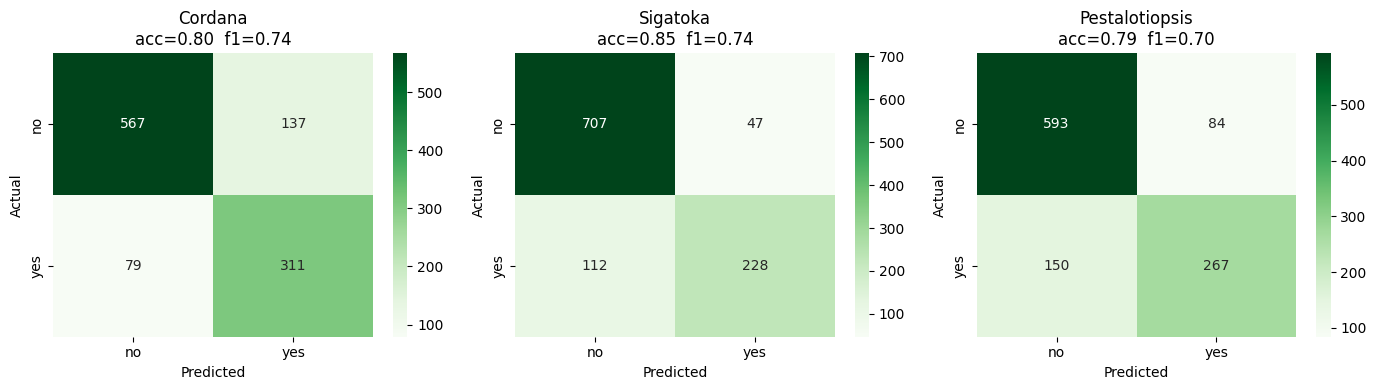

In [ ]:
disease_models = {}
disease_results = {}
disease_algorithms = {}

for i, name in enumerate(DISEASE_NAMES):
    winner = results_stage2[name].iloc[0]["Model"]
    disease_algorithms[name] = winner
    print(f"{name} detector winner from the comparison above: {winner}")
    model, best_params = tune_winner(winner, X2_train_s, Y2_train[:, i])
    disease_models[name] = model

    pred = model.predict(X2_test_s)
    acc = accuracy_score(Y2_test[:, i], pred)
    f1 = f1_score(Y2_test[:, i], pred)
    disease_results[name] = {"accuracy": acc, "f1": f1, "y_pred": pred, "best_params": best_params,
                              "algorithm": winner}
    print(f"--- {name} detector ({winner}) --- best_params={best_params}")
    print(classification_report(Y2_test[:, i], pred, target_names=[f"no {name}", f"has {name}"]))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, name in zip(axes, DISEASE_NAMES):
    cm = confusion_matrix(Y2_test[:, DISEASE_NAMES.index(name)], disease_results[name]["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
                xticklabels=["no", "yes"], yticklabels=["no", "yes"], ax=ax)
    ax.set_title(f"{name}\nacc={disease_results[name]['accuracy']:.2f}  f1={disease_results[name]['f1']:.2f}")
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout(); plt.show()


Check how accurate the three disease models are when their results are combined.

In [ ]:
pred_matrix = np.column_stack([disease_results[n]["y_pred"] for n in DISEASE_NAMES])
exact_match = (pred_matrix == Y2_test).all(axis=1).mean()
hamming = (pred_matrix != Y2_test).mean()

print(f"Exact-match accuracy (ALL 3 disease flags correct at once): {exact_match:.3f}")
print(f"Hamming loss (average per-label error rate):                {hamming:.3f}")

def flags_to_label(flags):
    names = [DISEASE_NAMES[i] for i, f in enumerate(flags) if f == 1]
    if not names:
        return "Healthy"
    return " + ".join(names)

report_rows = []
for i in range(len(Y2_test)):
    report_rows.append({
        "true": flags_to_label(Y2_test[i]),
        "predicted": flags_to_label(pred_matrix[i]),
    })
report_df = pd.DataFrame(report_rows)
print("\nSample predictions:")
report_df.sample(10, random_state=1)


Exact-match accuracy (ALL 3 disease flags correct at once): 0.591
Hamming loss (average per-label error rate):                0.186

Sample predictions:


,true,predicted
973,Cordana + Sigatoka + Pestalotiopsis,Cordana + Pestalotiopsis
435,Healthy,Healthy
1028,Cordana + Sigatoka,Cordana + Sigatoka
680,Pestalotiopsis,Pestalotiopsis
799,Sigatoka,Sigatoka
226,Cordana,Cordana + Pestalotiopsis
1027,Cordana + Sigatoka,Cordana + Sigatoka
81,Cordana,Cordana
437,Healthy,Pestalotiopsis
49,Cordana,Cordana


Show which features matter most in each disease model's decision.

AttributeError: 'SVC' object has no attribute 'feature_importances_'

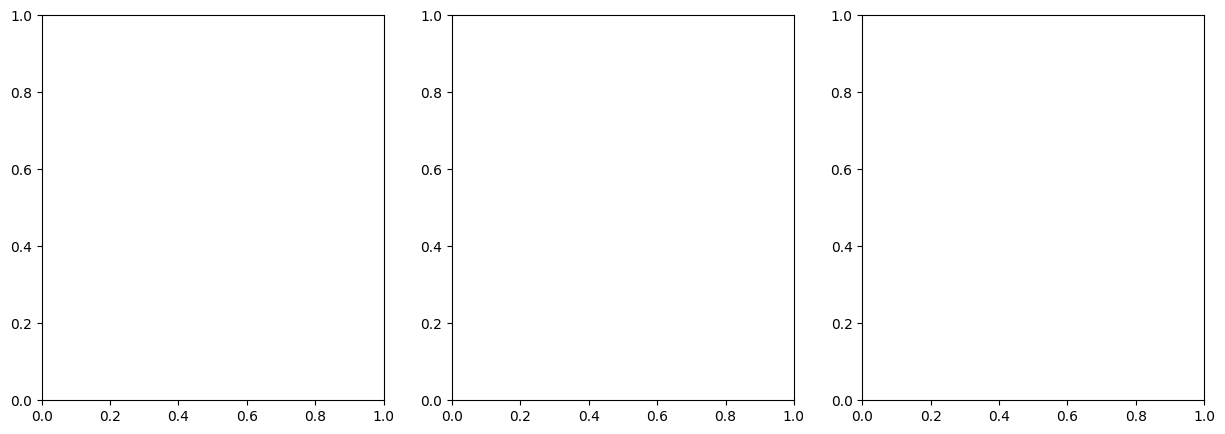

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name in zip(axes, DISEASE_NAMES):
    imp = pd.DataFrame({"feature": DISEASE_FEATURE_NAMES,
                         "importance": disease_models[name].feature_importances_}
                        ).sort_values("importance", ascending=False)
    sns.barplot(data=imp, x="importance", y="feature", color="#2E7D32", ax=ax)
    ax.set_title(f"{name} — feature importance")
plt.tight_layout(); plt.show()


This is the full prediction pipeline, from the photo to the final result: is it a leaf, does it have a disease, and which disease.

In [ ]:
LEAF_GATE_THRESHOLD = 0.5     # probability that it IS a banana leaf
DISEASE_THRESHOLD = 0.5        # probability that a given disease IS present

def predict_pipeline(path):
    img = cv2.imread(path)
    if img is None:
        return {"error": "could not read image"}

    # --- Stage 1: leaf gate ---
    lf = leaf_presence_features(img)
    lf_s = leaf_scaler.transform([lf])
    leaf_proba = leaf_model.predict_proba(lf_s)[0][1]
    if leaf_proba < LEAF_GATE_THRESHOLD:
        return {"is_banana_leaf": False, "leaf_confidence": float(leaf_proba),
                "result": "Not a banana leaf — no diagnosis performed."}

    # --- Stage 2: independent disease detectors ---
    df_feats = disease_features(img)
    df_s = disease_scaler.transform([df_feats])
    disease_proba = {}
    positives = []
    for name, model in disease_models.items():
        p = model.predict_proba(df_s)[0][1]
        disease_proba[name] = float(p)
        if p >= DISEASE_THRESHOLD:
            positives.append(name)

    # --- Stage 3: decision logic ---
    if not positives:
        result = "Healthy"
    elif len(positives) == 1:
        result = f"Single disease detected: {positives[0]}"
    else:
        result = f"Multiple diseases detected: {' + '.join(positives)}"

    return {
        "is_banana_leaf": True,
        "leaf_confidence": float(leaf_proba),
        "disease_probabilities": disease_proba,
        "diseases_detected": positives,
        "result": result,
    }

# quick demo across a few random images from each bucket
import random
random.seed(1)
demo_paths = (
    random.sample(list(full[full["class"] == "Healthy"]["path"]), 1) +
    random.sample(list(full[full["class"] == "Cordana"]["path"]), 1) +
    random.sample(list(full[full["class"] == "cordana_sigatoka"]["path"]), 1) +
    random.sample(list(full[full["class"].str.startswith("NEGATIVE")]["path"]), 2)
)
for p in demo_paths:
    r = predict_pipeline(p)
    print(os.path.basename(os.path.dirname(p)) + "/" + os.path.basename(p), "->", r["result"])


Save the trained models and scalers as .pkl files.

In [ ]:
import joblib

joblib.dump(leaf_model, "/content/leaf_gate_model.pkl")
joblib.dump(leaf_scaler, "/content/leaf_gate_scaler.pkl")
joblib.dump(disease_scaler, "/content/disease_scaler.pkl")
for name, model in disease_models.items():
    joblib.dump(model, f"/content/disease_{name.lower()}_model.pkl")

with open("/content/model_report.txt", "w") as f:
    f.write(f"=== Stage 1: Leaf Gate (algorithm: {leaf_gate_algorithm}) ===\n")
    f.write(classification_report(y1_test, pred1, target_names=["not leaf", "leaf"]))
    f.write("\n\n=== Stage 2: Disease Detectors ===\n")
    for name in DISEASE_NAMES:
        f.write(f"\n--- {name} (algorithm: {disease_results[name]['algorithm']}) ---\n")
        f.write(f"accuracy={disease_results[name]['accuracy']:.4f}  f1={disease_results[name]['f1']:.4f}\n")
        f.write(f"best_params={disease_results[name]['best_params']}\n")
    f.write(f"\nExact-match (all disease flags correct): {exact_match:.4f}\n")
    f.write(f"Hamming loss: {hamming:.4f}\n")

print("Saved all .pkl models + model_report.txt to /content/")


Export the models to ONNX format, as an alternate format.

In [ ]:
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.pipeline import Pipeline
import onnxruntime as ort

def export_pipeline_onnx(scaler, model, n_features, out_path, model_name):
    pipe = Pipeline([("scaler", scaler), ("clf", model)])
    onnx_model = convert_sklearn(
        pipe,
        initial_types=[("input", FloatTensorType([None, n_features]))],
        options={id(model): {"zipmap": False}},   # plain array output, easier to parse in Kotlin
        target_opset=13,
    )
    with open(out_path, "wb") as f:
        f.write(onnx_model.SerializeToString())
    print(f"Saved {out_path}")
    return out_path

onnx_paths = {}
onnx_paths["leaf_gate"] = export_pipeline_onnx(
    leaf_scaler, leaf_model, len(LEAF_FEATURE_NAMES),
    "/content/leaf_gate.onnx", "leaf_gate")

for name, model in disease_models.items():
    onnx_paths[name.lower()] = export_pipeline_onnx(
        disease_scaler, model, len(DISEASE_FEATURE_NAMES),
        f"/content/disease_{name.lower()}.onnx", name)

def verify_onnx(onnx_path, sklearn_scaler, sklearn_model, X_raw, y_true=None, label=""):
    sess = ort.InferenceSession(onnx_path)
    input_name = sess.get_inputs()[0].name
    onnx_out = sess.run(None, {input_name: X_raw.astype(np.float32)})
    onnx_pred = onnx_out[0]
    sk_pred = sklearn_model.predict(sklearn_scaler.transform(X_raw))
    match = (onnx_pred.ravel() == sk_pred.ravel()).mean()
    print(f"[{label}] ONNX vs sklearn prediction match: {match*100:.2f}%")
    return match

verify_onnx(onnx_paths["leaf_gate"], leaf_scaler, leaf_model, X1_test, y1_test, "leaf_gate")
for name in DISEASE_NAMES:
    verify_onnx(onnx_paths[name.lower()], disease_scaler, disease_models[name], X2_test, Y2_test[:, DISEASE_NAMES.index(name)], name)

print("\nIf all match rates are ~100%, the ONNX models are safe to ship to Android.")


Create model_metadata.json, which holds information about the features, thresholds, and settings used.

In [ ]:
import json as _json

metadata = {
    "leaf_feature_names": LEAF_FEATURE_NAMES,
    "disease_feature_names": DISEASE_FEATURE_NAMES,
    "disease_order": DISEASE_NAMES,
    "leaf_gate_threshold": LEAF_GATE_THRESHOLD,
    "disease_threshold": DISEASE_THRESHOLD,
    "img_size": IMG_SIZE,
    "hsv_lower": [15, 25, 25],
    "hsv_upper": [95, 255, 255],
    "segmentation_method": "kmeans+otsu",
    "leaf_gate_algorithm": leaf_gate_algorithm,
    "disease_algorithms": disease_algorithms,
}
with open("/content/model_metadata.json", "w") as f:
    _json.dump(metadata, f, indent=2)
print(_json.dumps(metadata, indent=2))

if leaf_gate_algorithm != "Random Forest" or any(a != "Random Forest" for a in disease_algorithms.values()):
    print("\n*** NOTE: SVM won at least one stage. The current Android app's on-device")
    print("inference (RandomForestModel.kt) only reads Random-Forest .bin exports -- it")
    print("cannot run an SVM. To deploy an SVM-selected head you'd need to switch that")
    print("head's on-device inference to the .onnx export below (onnxruntime-android) ***")


## Download everything
Run the cell below, then upload the downloaded files into your Android Studio project's `app/src/main/assets/` folder.

Download the .pkl and .onnx files to your computer.

In [ ]:
from google.colab import files as gfiles

DOWNLOAD_FILES = [
    "leaf_gate.onnx", "disease_cordana.onnx", "disease_sigatoka.onnx", "disease_pestalotiopsis.onnx",
    "leaf_gate_model.pkl", "leaf_gate_scaler.pkl", "disease_scaler.pkl",
    "disease_cordana_model.pkl", "disease_sigatoka_model.pkl", "disease_pestalotiopsis_model.pkl",
    "model_metadata.json", "model_report.txt",
]
for fname in DOWNLOAD_FILES:
    gfiles.download(f"/content/{fname}")

shutil.copy(FEATURES_CSV, "/content/features_all.csv")
gfiles.download("/content/features_all.csv")


The most important cell: export the Random Forest models to the custom .bin format the Android app can read (not TFLite or ONNX).

In [ ]:
import struct, os, numpy as np
from google.colab import files as gfiles

def export_rf_to_bin(model, out_path):
    n_classes = model.n_classes_
    n_features = model.n_features_in_
    with open(out_path, "wb") as f:
        f.write(struct.pack("<iii", len(model.estimators_), n_features, n_classes))
        for est in model.estimators_:
            tree = est.tree_
            f.write(struct.pack("<i", tree.node_count))
            for i in range(tree.node_count):
                feature = int(tree.feature[i])
                threshold = float(tree.threshold[i])
                left = int(tree.children_left[i])
                right = int(tree.children_right[i])
                counts = tree.value[i][0]
                total = counts.sum()
                probs = (counts / total) if total > 0 else np.zeros(n_classes)
                f.write(struct.pack("<ifii", feature, threshold, left, right))
                f.write(struct.pack(f"<{n_classes}f", *probs.astype(np.float32)))
    print(f"  wrote {out_path} ({os.path.getsize(out_path)/1024:.1f} KB)")

def kt_array(name, values):
    body = ",\n        ".join(repr(float(v)) for v in values)
    return f"    private val {name} = doubleArrayOf(\n        {body}\n    )"

print("Exporting Random Forest models...")
export_rf_to_bin(leaf_model, "/content/leaf_detector.bin")
export_rf_to_bin(disease_models["Cordana"], "/content/cordana.bin")
export_rf_to_bin(disease_models["Sigatoka"], "/content/sigatoka.bin")
export_rf_to_bin(disease_models["Pestalotiopsis"], "/content/pestalotiopsis.bin")

print("Exporting scaler values...")
kt_code = "\n\n".join([
    kt_array("LEAF_MEAN", leaf_scaler.mean_),
    kt_array("LEAF_SCALE", leaf_scaler.scale_),
    kt_array("DISEASE_MEAN", disease_scaler.mean_),
    kt_array("DISEASE_SCALE", disease_scaler.scale_),
])
with open("/content/FeatureScaler_snippet.txt", "w") as f:
    f.write(kt_code)
print("Done. Downloading all files now...")

for fname in ["leaf_detector.bin", "cordana.bin", "sigatoka.bin",
              "pestalotiopsis.bin", "FeatureScaler_snippet.txt"]:
    gfiles.download(f"/content/{fname}")